In [21]:
import pandas as pd
from pandas import to_datetime
import numpy as np
import re
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pymc as pm
import arviz as az
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent   # go up exactly one level
print("PROJECT_ROOT =", PROJECT_ROOT)

# Use it like this (no chdir needed):
# csv_path = PROJECT_ROOT / "shared_data" / "fetch_fred_data.csv"


PROJECT_ROOT = C:\Users\Eric\Documents\Python\forecast_system


In [3]:
import snowflake.connector
conn = snowflake.connector.connect(
    account="UBAZXIP-FCB79770",
    user="FORECAST_APP_USER",
    password="Hambone_66_!!!",
    warehouse="FORECAST_WH",
    database="FORECAST_DB",
    schema="SECURITY",
    role="FORECAST_APP_ROLE",
)
print("connected")
conn.close()

DatabaseError: 250001 (08001): Failed to connect to DB: UBAZXIP-FCB79770.snowflakecomputing.com:443. Multi-factor authentication is required for this account. Log in to Snowsight to enroll.

In [45]:
# ----------------------------------------------------------------------
    # STAGE 1 - Load data and config model
    # ----------------------------------------------------------------------
path = PROJECT_ROOT / "data" / "shared" /  'forecast_system_dataset.csv'   
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df[df['date'] >= '2009-01-01']

# Set the beginning and end dates for the training model
forecast_month = '_2025_08'
start_date_training = pd.to_datetime('2009-01-01')
end_date_training = pd.to_datetime('2025-07-01')

#Set the forward forecast dates
start_date_forecast = end_date_training + pd.DateOffset(months=1)
end_date_forecast = start_date_forecast + pd.DateOffset(months=6)

# MODEL VARIABLES
ind = ['oil_prices_yoy_lag7', 'oil_prices_yoy_lag8', 'oil_prices_yoy_lag9',
    'ppi_farm_products_yoy_lag4', 'ppi_farm_products_yoy_lag5', 'ppi_farm_products_yoy_lag6',
    'ppi_food_mfg_yoy_lag2', 'ppi_food_mfg_yoy_lag3', 'ppi_food_mfg_yoy_lag4', 
    'ppi_grocery_yoy', 'ppi_grocery_yoy_lag1', 'cpi_fah_yoy']
dep = 'avg_cost_yoy'

# Color for rolling forecast chart
color_map = {
    'Actuals': 'black',
    '_2025_02': 'blue',
    '_2025_04': 'red',
    '_2025_05': 'green',
    '_2025_06': 'orange',
    '_2025_07': 'grey',
    '_2025_08': 'yellow',
}


oil_prices_yoy
ppi_farm_products_yoy
ppi_food_mfg_yoy
ppi_grocery_yoy
import_ffb_yoy
cpi_fah_yoy
avg_cost_yoy
cpi_fah_yoy_lag1
cpi_fah_yoy_lag2
cpi_fah_yoy_lag3
cpi_fah_yoy_lag4
cpi_fah_yoy_lag5
cpi_fah_yoy_lag6
cpi_fah_yoy_lag7
cpi_fah_yoy_lag8
cpi_fah_yoy_lag9
cpi_fah_yoy_lag10
cpi_fah_yoy_lag11
cpi_fah_yoy_lag12
oil_prices_yoy_lag1
oil_prices_yoy_lag2
oil_prices_yoy_lag3
oil_prices_yoy_lag4
oil_prices_yoy_lag5
oil_prices_yoy_lag6
oil_prices_yoy_lag7
oil_prices_yoy_lag8
oil_prices_yoy_lag9
oil_prices_yoy_lag10
oil_prices_yoy_lag11
oil_prices_yoy_lag12
ppi_farm_products_yoy_lag1
ppi_farm_products_yoy_lag2
ppi_farm_products_yoy_lag3
ppi_farm_products_yoy_lag4
ppi_farm_products_yoy_lag5
ppi_farm_products_yoy_lag6
ppi_farm_products_yoy_lag7
ppi_farm_products_yoy_lag8
ppi_farm_products_yoy_lag9
ppi_farm_products_yoy_lag10
ppi_farm_products_yoy_lag11
ppi_farm_products_yoy_lag12
ppi_food_mfg_yoy_lag1
ppi_food_mfg_yoy_lag2
ppi_food_mfg_yoy_lag3
ppi_food_mfg_yoy_lag4
ppi_food_mfg_yoy_lag5
ppi

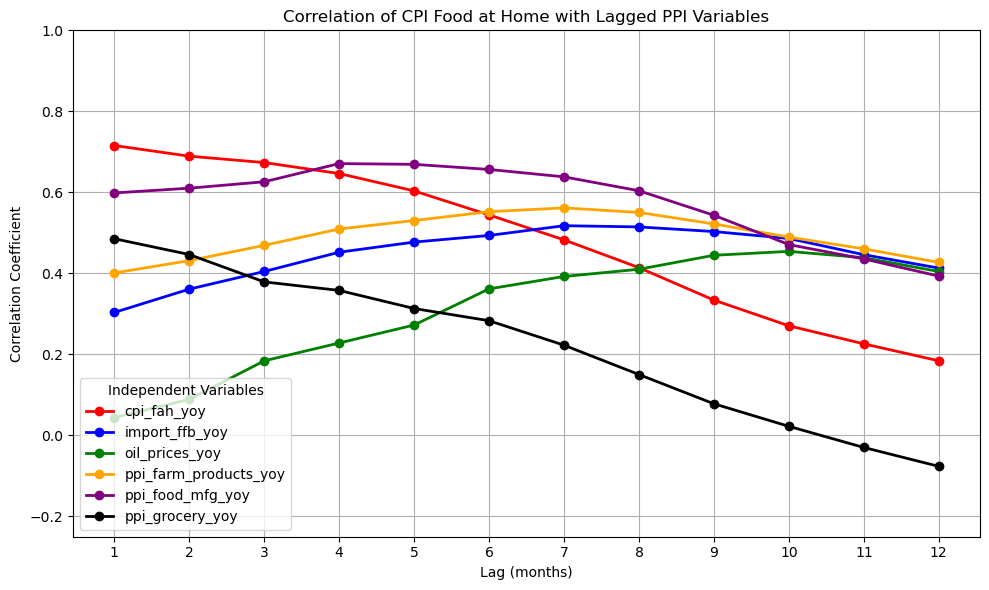

In [ ]:
df_cogs_ = df.reset_index().set_index('date')

cogs_vars = (
    'cpi_fah_yoy',
    'oil_prices_yoy',
    'ppi_farm_products_yoy',
    'ppi_food_mfg_yoy',
    'ppi_grocery_yoy',
    'import_ffb_yoy'
)
    
# pull out proper columns
mask = df_cogs_.columns.str.startswith(cogs_vars)
df = df_cogs_.loc[:, mask | (df_cogs_.columns == 'avg_cost_yoy')].copy()

# Compute correlation matrix with lagged variables
target_var = df["avg_cost_yoy"]
lag_mask = df.columns.str.contains(r'_lag')
lag_cols = df.columns[lag_mask].tolist()
corr_series = df[lag_cols].corrwith(target_var) 

# If you want a tidy DataFrame
corr_df = pd.DataFrame({'corr_with_avg_cost_yoy': corr_series}).reset_index().rename(columns={"index":"lag_vars"})
corr_df['lag'] = corr_df['lag_vars'].str.extract(r'lag(\d+)$', expand=False).astype('Int64').fillna(0)
corr_df['lag_vars'] = corr_df['lag_vars'].str.rsplit("_", n=1).str[0]
corr_df = corr_df.pivot(index='lag', columns='lag_vars', values='corr_with_avg_cost_yoy')

# create the lag corr plot
palette = ['red','blue','green','orange','purple','black',
           'magenta','cyan','brown','gold','navy','crimson']
        
fig, ax = plt.subplots(figsize=(10, 6))

for var, color in zip(corr_df.columns, palette):
     ax.plot(corr_df.index, corr_df[var], marker="o", linewidth=2, color=color, label=var)

ax.set_title('Correlation of CPI Food at Home with Lagged PPI Variables')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation Coefficient')
ax.set_xticks(corr_df.index)
ax.set_ylim(-0.25, 1)
ax.legend(title="Independent Variables", loc='lower left')
ax.grid(True)
fig.tight_layout()
